Sample cleaned text:

alice's adventures in wonderland     
 
 illustration  
 
 
 
 
alice s adventures in wonderland 
 
by lewis carroll 
 
the millennium fulcrum edition 3.0 
 
contents 
 
 chapter i.     down the rabbit hole 
 chapter ii.    the pool of tears 
 chapter iii.   a caucus race and a long tale 
 chapter iv.    the rabbit sends in a little bill 
 chapter v.     advice from a caterpillar 
 chapter vi.    pig and pepper 
 chapter vii.   a mad tea party 
 chapter viii.  the queen s croquet ground 
 chapte

Vocabulary size: 45

Training samples: (166781, 60)

Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 60, 64)    │      2,880 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     33,216 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 64)    │          0 │ embedding[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 60, 64)    │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3840)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 45)        │    172,845 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 225,773 (881.93 KB)

 Trainable params: 225,773 (881.93 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 2.3430
Epoch 2/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 2.0866
Epoch 3/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 2.0071
Epoch 4/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 1.9557
Epoch 5/5
2606/2606 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 1.9151


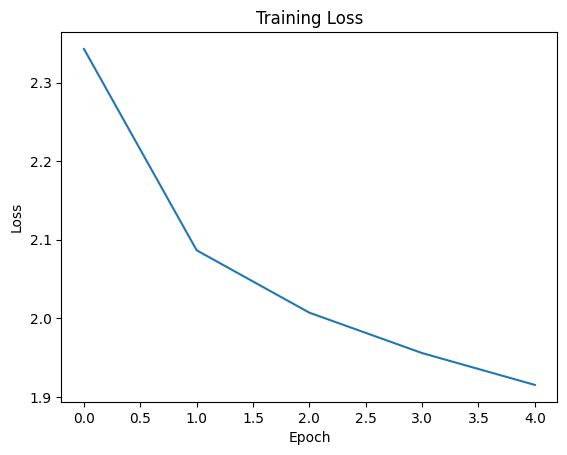


Seed:
 r ix.    the mock turtle s story 
 chapter x.     the lobste

Generated Text:
 r ix.    the mock turtle s story 
 chapter x.     the lobstere  i                                                                                                                                                                                                                                                                                                                                                                                                           

Content Creation Seed:
 in this story about a magical forest adventure, alice's adve

Generated Story Snippet:
 in this story about a magical forest adventure, alice's adveny with allece sait  ou d the  o the  ore  or         
 
                                                                                                                                                                                                                              

In [1]:
# =========================================================
# 1. IMPORTS
# =========================================================
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import requests
import re

# =========================================================
# 2. LOAD PUBLIC DOMAIN TEXT (PROJECT GUTENBERG)
# =========================================================
url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"  # Alice in Wonderland (public domain)
response = requests.get(url)
text = response.text

# Remove header/footer
start_idx = text.find("ALICE’S ADVENTURES IN WONDERLAND")
if start_idx == -1:
    start_idx = text.find("ALICE'S ADVENTURES IN WONDERLAND")
clean_text = text[start_idx:]

# Lowercase + keep basic characters
clean_text = clean_text.lower()
clean_text = re.sub(r'[^a-z0-9 .,;:!?\'\"\n]', ' ', clean_text)

# LIMIT TEXT SIZE TO PREVENT GPU CRASH
clean_text = clean_text[:200000]  # 200k chars fits safely in Colab

print("Sample cleaned text:\n")
print(clean_text[:500])

# =========================================================
# 3. CHARACTER-LEVEL TOKENIZATION
# =========================================================
chars = sorted(list(set(clean_text)))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
vocab_size = len(chars)

print("\nVocabulary size:", vocab_size)

# Convert entire text to integer tokens
encoded = np.array([char_to_idx[c] for c in clean_text])

# =========================================================
# 4. CREATE TRAINING SEQUENCES (NO ONE-HOT)
# =========================================================
seq_length = 60  # shorter = safer for memory

X = []
y = []

for i in range(len(encoded) - seq_length):
    X.append(encoded[i:i+seq_length])
    y.append(encoded[i+seq_length])

X = np.array(X)
y = np.array(y)

print("\nTraining samples:", X.shape)

# =========================================================
# 5. BUILD MINI GPT-STYLE TRANSFORMER MODEL
# =========================================================
embed_dim = 64
num_heads = 2
ff_dim = 128

inputs = layers.Input(shape=(seq_length,))
x = layers.Embedding(vocab_size, embed_dim)(inputs)

# Self-attention block
attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)

# Feed-forward block
ff = layers.Dense(ff_dim, activation="relu")(x)
ff = layers.Dense(embed_dim)(ff)
x = layers.Add()([x, ff])
x = layers.LayerNormalization()(x)

# Output: predict next character
x = layers.Flatten()(x)
outputs = layers.Dense(vocab_size, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy")

print("\nModel Summary:")
model.summary()

# =========================================================
# 6. TRAIN THE MODEL
# =========================================================
history = model.fit(
    X, y,
    batch_size=64,
    epochs=5
)

# =========================================================
# 7. PLOT TRAINING LOSS
# =========================================================
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# =========================================================
# 8. TEXT GENERATION FUNCTION
# =========================================================
def generate_text(model, seed, length=400):
    seed = seed.lower()
    seed = re.sub(r'[^a-z0-9 .,;:!?\'\"\n]', ' ', seed)

    # Ensure seed length
    if len(seed) < seq_length:
        seed = seed + " " * (seq_length - len(seed))
    else:
        seed = seed[:seq_length]

    generated = seed

    for _ in range(length):
        x = np.array([[char_to_idx.get(c, 0) for c in generated[-seq_length:]]])
        preds = model.predict(x, verbose=0)[0]
        next_idx = np.argmax(preds)
        next_char = idx_to_char[next_idx]
        generated += next_char

    return generated

# =========================================================
# 9. GENERATE TEXT FROM SEED
# =========================================================
seed = clean_text[500:500+seq_length]
print("\nSeed:\n", seed)

generated = generate_text(model, seed)
print("\nGenerated Text:\n", generated)

# =========================================================
# 10. CONTENT CREATION DEMO
# =========================================================
topic = "a magical forest adventure"
seed_demo = f"in this story about {topic}, "
seed_demo = (seed_demo + clean_text[:seq_length])[:seq_length]

print("\nContent Creation Seed:\n", seed_demo)

generated_story = generate_text(model, seed_demo)
print("\nGenerated Story Snippet:\n", generated_story)